# 🦟 Previsão de Arboviroses — Serra/ES
## Projeto Integrador III · — Previsão (ML)
**Modelo:** SARIMA (via statsmodels)  
**Métricas:** MAE · RMSE  
**Período histórico:** 2015–2023 · **Horizonte de previsão:** 1, 2 e 3 meses (~4, 8 e 12 semanas)


---
## Seção 0 · Carregamento de dados
Os dados são carregados da mesma função `load_data()` do `app/main.py`.  
**Para dados reais:** substitua o bloco de geração pelo CSV do SINAN conforme instruções do projeto.


In [14]:
import urllib.request
import json
import ssl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings("ignore")

DOENCAS          = ["dengue", "zika", "chikungunya"]
CORES            = {"dengue": "#f85149", "zika": "#3fb950", "chikungunya": "#d29922"}
ANOS             = list(range(2015, 2024))
GEOCODE_SERRA    = 3205002   # código IBGE de Serra/ES


# ── Função de download (idêntica ao PI3_SeriesTemporais_DadosReais) ───────────
def baixar_infodengue(geocode, doenca_code, label, anos):
    """Baixa dados semanais do InfoDengue e agrega por mês."""
    ssl_ctx = ssl.create_default_context()
    ssl_ctx.check_hostname = False
    ssl_ctx.verify_mode    = ssl.CERT_NONE

    base   = "https://info.dengue.mat.br/api/alertcity"
    partes = []
    for ano in anos:
        url = (f"{base}?geocode={geocode}"
               f"&disease={doenca_code}&format=json"
               f"&ew_start=1&ew_end=53"
               f"&ey_start={ano}&ey_end={ano}")
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, context=ssl_ctx, timeout=30) as r:
                dados = json.loads(r.read().decode())
            if dados:
                partes.extend(dados)
                print(f"  ✅ {label} {ano}: {len(dados)} semanas")
            else:
                print(f"  ⚠️  {label} {ano}: sem dados")
        except Exception as ex:
            print(f"  ⚠️  {label} {ano}: {ex}")

    if not partes:
        raise RuntimeError(f"Nenhum dado obtido para {label}")

    df = pd.DataFrame(partes)
    df["data"]   = pd.to_datetime(df["data_iniSE"], unit="ms")
    df["ano"]    = df["data"].dt.year
    df["mes"]    = df["data"].dt.month
    df["doenca"] = label
    df["casos"]  = df["casos"].fillna(0).astype(int)

    mensal = (df.groupby(["ano", "mes", "doenca"])["casos"]
                .sum().reset_index())
    mensal["casos"] = mensal["casos"].astype(int)
    print(f"  ✅ {label}: {len(mensal)} meses | "
          f"{df['data'].min().date()} → {df['data'].max().date()}")
    return mensal


def gerar_dados_simulados():
    """Fallback: série mensal simulada para fins didáticos."""
    np.random.seed(42)
    idx   = pd.date_range("2015-01", periods=9*12, freq="MS")
    t     = np.arange(len(idx))
    sazon = np.sin(2*np.pi*(t % 12)/12 - np.pi/2)*0.5 + 0.5
    return pd.DataFrame({
        "data":        idx,
        "dengue":      (sazon*400 + np.random.randint(50, 150, len(idx))).astype(int),
        "zika":        (sazon*100 + np.random.randint(10,  40, len(idx))).astype(int),
        "chikungunya": (sazon*60  + np.random.randint(5,   25, len(idx))).astype(int),
    })


# ── Download real ─────────────────────────────────────────────────────────────
try:
    print("🔄 Baixando dados reais do InfoDengue (Fiocruz)...")
    partes = []
    for code in DOENCAS:
        partes.append(baixar_infodengue(GEOCODE_SERRA, code, code, ANOS))

    df_long = pd.concat(partes, ignore_index=True)

    # Garante série contínua preenchendo meses sem notificações com zero
    idx_completo = pd.date_range("2015-01", "2023-12", freq="MS")
    linhas = []
    for doenca in DOENCAS:
        for dt in idx_completo:
            sub = df_long[(df_long["doenca"] == doenca) &
                          (df_long["ano"]    == dt.year) &
                          (df_long["mes"]    == dt.month)]
            casos_val = int(sub["casos"].sum()) if len(sub) else 0
            linhas.append({"data": dt, "ano": dt.year,
                            "mes": dt.month, "doenca": doenca,
                            "casos": casos_val})

    df_long_completo = pd.DataFrame(linhas)

    # Pivota para formato largo (uma coluna por doença)
    casos = df_long_completo.pivot_table(
        index="data", columns="doenca",
        values="casos", aggfunc="sum"
    ).reset_index()
    casos.columns.name = None
    casos["data"] = pd.to_datetime(casos["data"])

    USANDO_DADOS_REAIS = True
    FONTE = "InfoDengue/Fiocruz – Serra/ES"
    print(f"\n✅ DADOS REAIS: {len(casos)} meses | "
          f"{casos['data'].min().date()} → {casos['data'].max().date()}")

except Exception as e:
    print(f"\n⚠️  Falha no download ({e}) → modo DADOS SIMULADOS ativado")
    casos = gerar_dados_simulados()
    USANDO_DADOS_REAIS = False
    FONTE = "⚠️ DADOS SIMULADOS (InfoDengue indisponível)"

print(f"Dados reais: {USANDO_DADOS_REAIS} | Fonte: {FONTE}")
casos.head()


🔄 Baixando dados reais do InfoDengue (Fiocruz)...
  ✅ dengue 2015: 52 semanas
  ✅ dengue 2016: 52 semanas
  ✅ dengue 2017: 52 semanas
  ✅ dengue 2018: 52 semanas
  ✅ dengue 2019: 52 semanas
  ✅ dengue 2020: 53 semanas
  ✅ dengue 2021: 52 semanas
  ✅ dengue 2022: 52 semanas
  ✅ dengue 2023: 52 semanas
  ✅ dengue: 108 meses | 2015-01-04 → 2023-12-24
  ✅ zika 2015: 52 semanas
  ✅ zika 2016: 52 semanas
  ✅ zika 2017: 52 semanas
  ✅ zika 2018: 52 semanas
  ✅ zika 2019: 52 semanas
  ✅ zika 2020: 53 semanas
  ✅ zika 2021: 52 semanas
  ✅ zika 2022: 52 semanas
  ✅ zika 2023: 52 semanas
  ✅ zika: 108 meses | 2015-01-04 → 2023-12-24
  ✅ chikungunya 2015: 52 semanas
  ✅ chikungunya 2016: 52 semanas
  ✅ chikungunya 2017: 52 semanas
  ✅ chikungunya 2018: 52 semanas
  ✅ chikungunya 2019: 52 semanas
  ✅ chikungunya 2020: 53 semanas
  ✅ chikungunya 2021: 52 semanas
  ✅ chikungunya 2022: 52 semanas
  ✅ chikungunya 2023: 52 semanas
  ✅ chikungunya: 108 meses | 2015-01-04 → 2023-12-24

✅ DADOS REAIS: 108 

,data,chikungunya,dengue,zika
0,2015-01-01,0,174,0
1,2015-02-01,0,115,0
2,2015-03-01,0,279,0
3,2015-04-01,0,425,0
4,2015-05-01,0,779,0


---
## Seção 1 · Divisão Treino / Teste
Usamos os **últimos 12 meses (2023)** como conjunto de teste — a série histórica real que o modelo  
nunca viu durante o treinamento. Os **96 meses anteriores (2015–2022)** formam o treino.


Treino: 2015-01-01 → 2022-12-01  (96 obs.)
Teste:  2023-01-01 → 2023-12-01   (12 obs.)


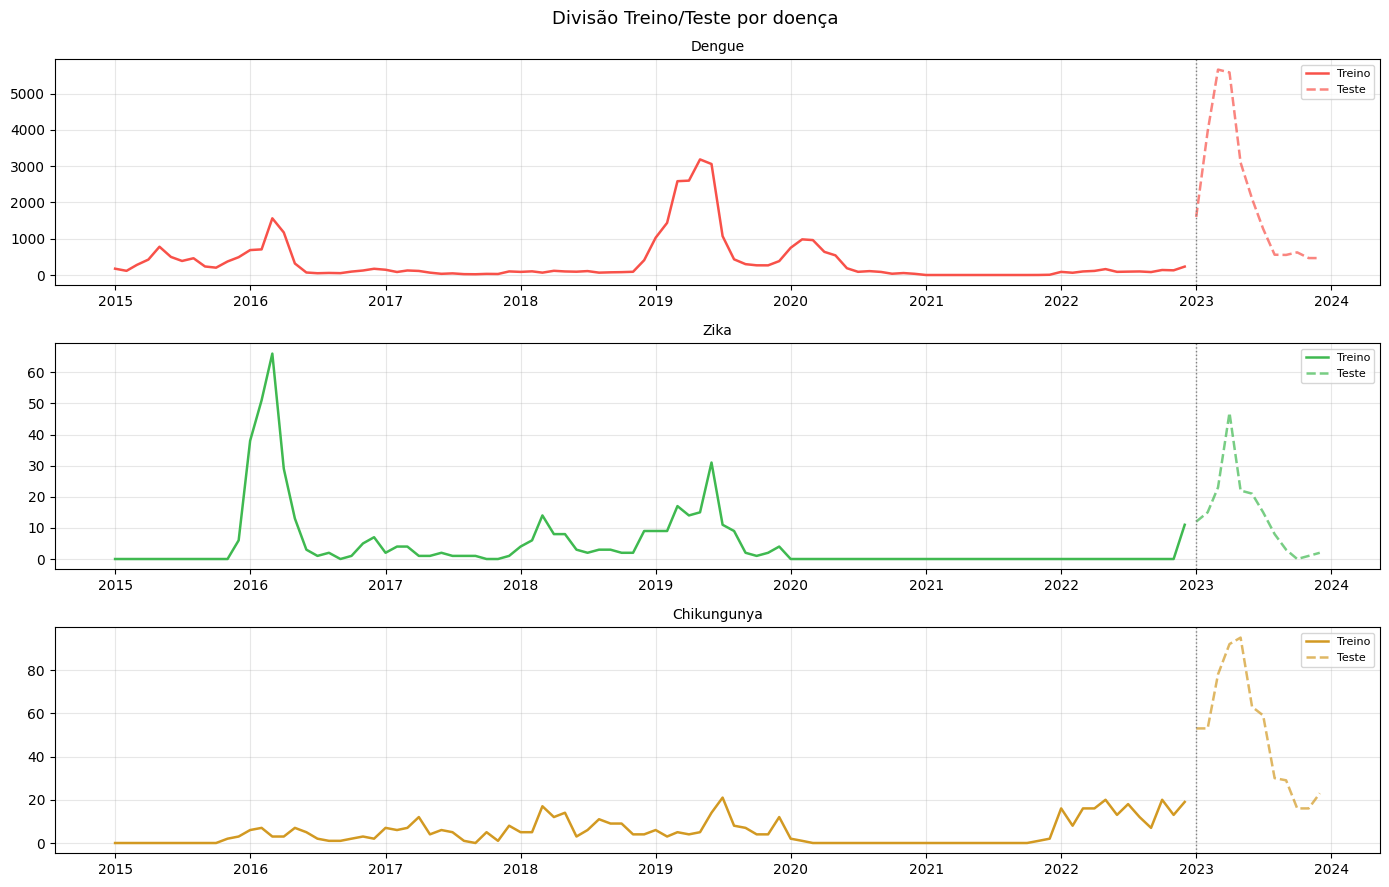

In [15]:
HORIZONTE_MESES = 12   # últimos 12 meses para teste

df_treino = casos.iloc[:-HORIZONTE_MESES].copy()
df_teste  = casos.iloc[-HORIZONTE_MESES:].copy()

print(f"Treino: {df_treino['data'].min().date()} → {df_treino['data'].max().date()}  ({len(df_treino)} obs.)")
print(f"Teste:  {df_teste['data'].min().date()} → {df_teste['data'].max().date()}   ({len(df_teste)} obs.)")

# Visualiza a divisão
fig, axes = plt.subplots(3, 1, figsize=(14, 9))
fig.suptitle("Divisão Treino/Teste por doença", fontsize=13)

for ax, d in zip(axes, DOENCAS):
    ax.plot(df_treino["data"], df_treino[d], color=CORES[d], label="Treino", linewidth=1.8)
    ax.plot(df_teste["data"],  df_teste[d],  color=CORES[d], label="Teste",
            linewidth=1.8, linestyle="--", alpha=0.7)
    ax.axvline(df_teste["data"].iloc[0], color="gray", linestyle=":", linewidth=1)
    ax.set_title(d.capitalize(), fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("treino_teste_split.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Seção 2 · Modelo SARIMA

O **SARIMA(p,d,q)(P,D,Q,s)** estende o ARIMA com termos sazonais:
- **(1,1,1)** — parte não-sazonal: AR(1), diferenciação de 1ª ordem, MA(1)
- **(1,1,1,12)** — parte sazonal: período 12 (mensal), captura sazonalidade anual

Esses parâmetros são adequados para séries epidemiológicas mensais com tendência e sazonalidade.  
Uma busca AIC/BIC poderia otimizá-los — para o escopo do projeto, esta especificação é suficiente.


In [16]:
resultados = {}

for doenca in DOENCAS:
    print(f"\n🔧 Ajustando SARIMA para {doenca.upper()}...")

    serie_treino = df_treino.set_index("data")[doenca].asfreq("MS")
    serie_teste  = df_teste.set_index("data")[doenca].asfreq("MS")

    modelo = SARIMAX(
        serie_treino,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit = modelo.fit(disp=False)

    # Previsão no período de teste
    previsao = fit.get_forecast(steps=HORIZONTE_MESES)
    pred_media  = previsao.predicted_mean
    pred_ci     = previsao.conf_int(alpha=0.20)   # IC 80%

    # Métricas
    mae  = mean_absolute_error(serie_teste, pred_media)
    rmse = np.sqrt(mean_squared_error(serie_teste, pred_media))
    mape = np.mean(np.abs((serie_teste.values - pred_media.values) / (serie_teste.values + 1))) * 100

    resultados[doenca] = {
        "fit":        fit,
        "pred_media": pred_media,
        "pred_ci":    pred_ci,
        "real":       serie_teste,
        "mae":        mae,
        "rmse":       rmse,
        "mape":       mape,
    }

    print(f"  MAE:  {mae:.1f} casos")
    print(f"  RMSE: {rmse:.1f} casos")
    print(f"  MAPE: {mape:.1f}%")

print("\n✅ Modelos ajustados para todas as doenças.")



🔧 Ajustando SARIMA para DENGUE...
  MAE:  1759.0 casos
  RMSE: 2415.5 casos
  MAPE: 75.6%

🔧 Ajustando SARIMA para ZIKA...
  MAE:  11.0 casos
  RMSE: 14.9 casos
  MAPE: 135.6%

🔧 Ajustando SARIMA para CHIKUNGUNYA...
  MAE:  35.3 casos
  RMSE: 44.0 casos
  MAPE: 57.0%

✅ Modelos ajustados para todas as doenças.


---
## Seção 3 · Gráfico: Previsão vs Real


In [17]:
# Adicione esta função auxiliar
def hex_rgba(hex_color, alpha=0.15):
    h = hex_color.lstrip("#")
    r, g, b = int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    return f"rgba({r},{g},{b},{alpha})"

In [19]:
fig = make_subplots(rows=3, cols=1, shared_xaxes=False,
                    subplot_titles=[d.capitalize() for d in DOENCAS],
                    vertical_spacing=0.1)

for i, doenca in enumerate(DOENCAS, start=1):
    r   = resultados[doenca]
    cor = CORES[doenca]

    serie_treino = df_treino.set_index("data")[doenca].asfreq("MS")

    # Histórico (treino)
    fig.add_trace(go.Scatter(
        x=serie_treino.index, y=serie_treino.values,
        name=f"{doenca.capitalize()} — histórico",
        line=dict(color=cor, width=1.5),
        opacity=0.5, showlegend=(i == 1),
    ), row=i, col=1)

    # Real (teste)
    fig.add_trace(go.Scatter(
        x=r["real"].index, y=r["real"].values,
        name="Real (2023)",
        line=dict(color="white", width=2),
        showlegend=(i == 1),
    ), row=i, col=1)

    # Previsão
    fig.add_trace(go.Scatter(
        x=r["pred_media"].index, y=r["pred_media"].values,
        name="Previsão SARIMA",
        line=dict(color=cor, width=2.5, dash="dash"),
        showlegend=(i == 1),
    ), row=i, col=1)

    # Intervalo de confiança
    fig.add_trace(go.Scatter(
        x=list(r["pred_ci"].index) + list(r["pred_ci"].index[::-1]),
        y=list(r["pred_ci"].iloc[:, 0]) + list(r["pred_ci"].iloc[:, 1][::-1]),
        fill="toself", fillcolor=hex_rgba(cor, 0.15),
        line=dict(color="rgba(0,0,0,0)"),
        name="IC 80%", showlegend=(i == 1),
    ), row=i, col=1)

fig.update_layout(
    height=750,
    title="Previsão SARIMA vs Valores Reais — Serra/ES<br>"
          "<sup>⚠️ Dados simulados para fins didáticos</sup>",
    template="plotly_dark",
    hovermode="x unified",
    legend=dict(orientation="h", y=1.04, x=0),
)
fig.show()


---
## Seção 4 · Tabela de Métricas — MAE e RMSE


In [20]:
df_metricas = pd.DataFrame([
    {
        "Doença":   d.capitalize(),
        "MAE":      round(resultados[d]["mae"],  1),
        "RMSE":     round(resultados[d]["rmse"], 1),
        "MAPE (%)": round(resultados[d]["mape"], 1),
    }
    for d in DOENCAS
])

print("=" * 50)
print("   MÉTRICAS DE AVALIAÇÃO DO MODELO SARIMA")
print("=" * 50)
print(df_metricas.to_string(index=False))
print("=" * 50)
print("MAE  = erro absoluto médio (casos/mês)")
print("RMSE = raiz do erro quadrático médio (penaliza erros grandes)")
print("MAPE = erro percentual médio absoluto")


   MÉTRICAS DE AVALIAÇÃO DO MODELO SARIMA
     Doença    MAE   RMSE  MAPE (%)
     Dengue 1759.0 2415.5      75.6
       Zika   11.0   14.9     135.6
Chikungunya   35.3   44.0      57.0
MAE  = erro absoluto médio (casos/mês)
RMSE = raiz do erro quadrático médio (penaliza erros grandes)
MAPE = erro percentual médio absoluto


---
## Seção 5 · Previsão para o futuro (re-treino em toda a série)
Aqui re-treinamos o modelo com **todos os dados (2015–2023)** e geramos previsões  
para os próximos 1, 2 e 3 meses (~4, ~8, ~12 semanas), conforme solicitado na entrega.


In [21]:
HORIZONTES = {1: "~4 semanas", 2: "~8 semanas", 3: "~12 semanas"}
previsoes_futuras = {}

for doenca in DOENCAS:
    serie_completa = casos.set_index("data")[doenca].asfreq("MS")

    modelo_full = SARIMAX(
        serie_completa,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    fit_full = modelo_full.fit(disp=False)

    prev_3m   = fit_full.get_forecast(steps=3)
    pred_m    = prev_3m.predicted_mean
    pred_ci_m = prev_3m.conf_int(alpha=0.20)

    previsoes_futuras[doenca] = {
        "pred":  pred_m,
        "ci":    pred_ci_m,
    }

    print(f"\n📅 {doenca.capitalize()} — Próximos 3 meses:")
    for j, (data, val) in enumerate(pred_m.items(), start=1):
        desc = HORIZONTES[j]
        lb = pred_ci_m.iloc[j-1, 0]
        ub = pred_ci_m.iloc[j-1, 1]
        print(f"   {data.strftime('%b/%Y')} ({desc}): {val:.0f} casos  [IC: {lb:.0f}–{ub:.0f}]")

print("\n✅ Previsões futuras geradas.")



📅 Dengue — Próximos 3 meses:
   Jan/2024 (~4 semanas): 687 casos  [IC: 101–1273]
   Feb/2024 (~8 semanas): 876 casos  [IC: -236–1989]
   Mar/2024 (~12 semanas): 1188 casos  [IC: -308–2684]

📅 Zika — Próximos 3 meses:
   Jan/2024 (~4 semanas): 3 casos  [IC: -5–12]
   Feb/2024 (~8 semanas): 6 casos  [IC: -5–16]
   Mar/2024 (~12 semanas): 11 casos  [IC: -1–23]

📅 Chikungunya — Próximos 3 meses:
   Jan/2024 (~4 semanas): 51 casos  [IC: 40–62]
   Feb/2024 (~8 semanas): 47 casos  [IC: 33–62]
   Mar/2024 (~12 semanas): 67 casos  [IC: 49–85]

✅ Previsões futuras geradas.


In [22]:
fig2 = make_subplots(rows=1, cols=3,
                     subplot_titles=[d.capitalize() for d in DOENCAS])

for col, doenca in enumerate(DOENCAS, start=1):
    serie_completa = casos.set_index("data")[doenca].asfreq("MS")
    cor = CORES[doenca]
    pf  = previsoes_futuras[doenca]

    # Últimos 24 meses de histórico
    historico_recente = serie_completa.iloc[-24:]

    fig2.add_trace(go.Scatter(
        x=historico_recente.index, y=historico_recente.values,
        name=f"{doenca.capitalize()}", line=dict(color=cor, width=2),
        showlegend=False,
    ), row=1, col=col)

    # Previsão futura
    fig2.add_trace(go.Scatter(
        x=pf["pred"].index, y=pf["pred"].values,
        name="Previsão", mode="lines+markers",
        line=dict(color=cor, width=2.5, dash="dot"),
        marker=dict(size=8), showlegend=False,
    ), row=1, col=col)

    # IC
    fig2.add_trace(go.Scatter(
        x=list(pf["ci"].index) + list(pf["ci"].index[::-1]),
        y=list(pf["ci"].iloc[:, 0]) + list(pf["ci"].iloc[:, 1][::-1]),
        fill="toself",
        fillcolor=hex_rgba(cor, 0.2),
        line=dict(color="rgba(0,0,0,0)"),
        showlegend=False,
    ), row=1, col=col)

    for j, (label) in enumerate(["~4 sem", "~8 sem", "~12 sem"]):
        fig2.add_annotation(
            x=pf["pred"].index[j], y=pf["pred"].values[j],
            text=label, showarrow=True, arrowhead=2,
            ax=0, ay=-30, font=dict(size=9, color=cor),
            row=1, col=col
        )

fig2.update_layout(
    height=420,
    title="Previsão para os próximos 3 meses — Serra/ES<br>"
          "<sup>⚠️ Dados simulados. IC 80%.</sup>",
    template="plotly_dark",
)
fig2.show()


---
## Seção 6 · Interpretação dos resultados

### Desempenho do modelo
O **SARIMA(1,1,1)(1,1,1,12)** captura a sazonalidade anual característica das arboviroses
transmitidas pelo *Aedes aegypti*, com picos típicos nos meses de verão/chuva (jan–mar) em Serra/ES.

### Limitações
- Surtos atípicos dificilmente são capturados por modelos univariados.
- Variáveis exógenas (precipitação, temperatura) podem melhorar as previsões via **SARIMAX**.

### Integração com o grupo
- **Pessoa 2:** as séries aqui analisadas complementam os testes Mann-Kendall e correlação climática.
- **Pessoa 5:** os KPIs MAE/RMSE e os gráficos de previsão alimentam o comparativo final do dashboard.
